[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AnahitShekikyan/ml-with-python-for-high-school-students/blob/main/chapter_03_data_preparation/chapter_3_3_data_balancing_and_train_test_split.ipynb)

# ⚖️ Chapter 3.3: Data Balancing & Train/Test Split

## Why Does This Matter?

You've cleaned your data (3.1) and explored it (3.2). Now it's time to **prepare it for the ML model**.

Two critical steps before training any model:
1. **Check for imbalanced data** — if your data is skewed heavily toward one outcome, your model will be biased
2. **Split into train and test sets** — so you can honestly evaluate how well the model works

> 📌 **Note:** Make sure you've run Chapter 3.1 first — this notebook uses `spotify_tracks_clean.csv`.

---

### 🎯 Learning Goals

| # | Goal |
|---|------|
| 1 | Understand what class imbalance is and why it's a problem |
| 2 | Encode categorical features for ML |
| 3 | Understand the train/test split concept |
| 4 | Split data correctly using scikit-learn |
| 5 | Understand why we never train and test on the same data |

---
## ⚙️ Setup — Load the Clean Dataset and Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df = pd.read_csv("spotify_tracks_clean.csv")
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(3)

Loaded: 113550 rows × 20 columns


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,Acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,Acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,Acoustic


---
## 3.3.1 Warm-Up 

> 🏋️ **Think about it first:**
>
> 1. Imagine you trained an AI spam detector on 990 normal emails and only 10 spam emails. What would happen?
> 2. If you studied from a textbook and then took a test using the **same exact questions**, would your score be a fair measure of what you know?
> 3. Why do teachers use different questions on the exam than in the practice exercises?

**✏️ Your answers here:**

1. 

2. 

3. 

---
## 3.3.2 Class Imbalance ⚖️

**Class imbalance** happens when one outcome is much more common than another in a dataset.

In our Spotify dataset, let's create a classification task: predict whether a song is **"Hit"** (popularity ≥ 60) or **"Not a Hit"** (popularity < 60).

If most songs are "Not a Hit", a model could get high accuracy just by **always predicting "Not a Hit"** — even if it learned absolutely nothing!

```
Example of imbalanced classes:

  Not a Hit: ████████████████████████ 90%
  Hit:       ██ 10%

  A model that always says "Not a Hit" would be 90% accurate
  — but completely useless!
```

In [12]:
# create a binary label: 'hit' = 1 if popularity >= 60, else 0
df['is_hit'] = (df['popularity'] >= 60).astype(int)

hit_counts = df['is_hit'].value_counts()
print("Class distribution:")
print(f"  Not a Hit (0): {hit_counts[0]} songs ({hit_counts[0]/len(df)*100:.1f}%)")
print(f"  Hit       (1): {hit_counts[1]} songs ({hit_counts[1]/len(df)*100:.1f}%)")

Class distribution:
  Not a Hit (0): 98738 songs (87.0%)
  Hit       (1): 14812 songs (13.0%)


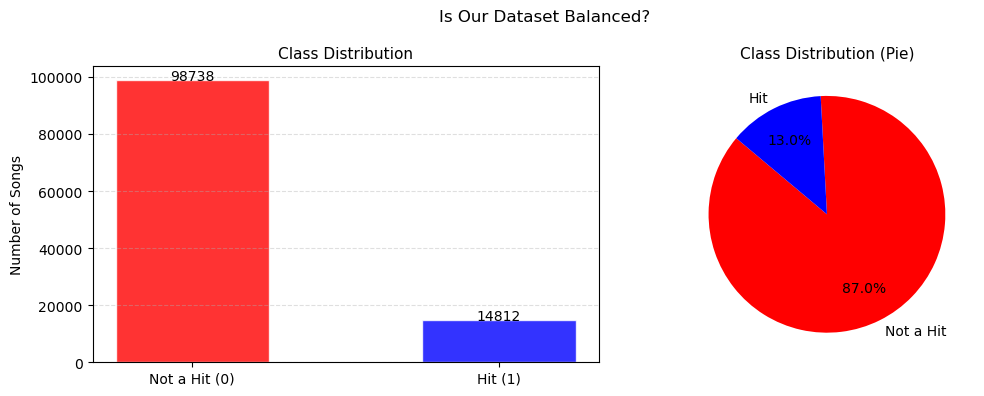

In [13]:
# visualize the imbalance
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# bar chart
colors = ['red', 'blue']
axes[0].bar(['Not a Hit (0)', 'Hit (1)'],
            [hit_counts[0], hit_counts[1]],
            color=colors, alpha=0.8, edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution', fontsize=11)
axes[0].set_ylabel('Number of Songs', fontsize=10)
for i, (label, val) in enumerate(zip(['Not a Hit', 'Hit'], [hit_counts[0], hit_counts[1]])):
    axes[0].text(i, val + 1, str(val), ha='center', fontsize=10)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.4)

# pie chart
axes[1].pie([hit_counts[0], hit_counts[1]],
            labels=['Not a Hit', 'Hit'],
            colors=colors, autopct='%1.1f%%',
            startangle=140, pctdistance=0.7)
axes[1].set_title('Class Distribution (Pie)', fontsize=11)

plt.suptitle('Is Our Dataset Balanced?', fontsize=12)
plt.tight_layout()
plt.show()

> 🏋️ **Practice 1:**
> 1. Is our dataset balanced or imbalanced? By how much?
> 2. If we built a model that always predicted "Not a Hit" — what accuracy would it get?
> 3. Would that model actually be useful? Why or why not?

**✏️ Your answers here:**

1. 

2. 

3. 

### Handling Imbalance — Undersampling

One simple fix is **undersampling** — reducing the majority class to match the minority class.

```
BEFORE undersampling:          AFTER undersampling:

Not a Hit: ████████████ 150    Not a Hit: ████ 50
Hit:       ██ 50               Hit:       ████ 50

We randomly remove rows from the majority class.
```

> ⚠️ Undersampling means we **lose data**. This is fine for a small dataset demonstration, but in real projects, more advanced methods like **SMOTE** (Synthetic Minority Oversampling) are preferred.
> 
> 💡 Unlike undersampling, SMOTE doesn't just repeat existing minority examples, it **creates brand-new artificial ones** by blending features between similar data points. This keeps more of your data while fixing the imbalance.

In [14]:
# undersample the majority class (Not a Hit) to match the minority class (Hit)
hits = df[df['is_hit'] == 1]
not_hits = df[df['is_hit'] == 0]

# randomly sample from the majority class
not_hits_sampled = not_hits.sample(n=len(hits), random_state=42)

# combine and shuffle
df_balanced = pd.concat([hits, not_hits_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)

print("AFTER undersampling:")
print(df_balanced['is_hit'].value_counts())
print(f"\nNew dataset size: {len(df_balanced)} rows")

AFTER undersampling:
is_hit
1    14812
0    14812
Name: count, dtype: int64

New dataset size: 29624 rows


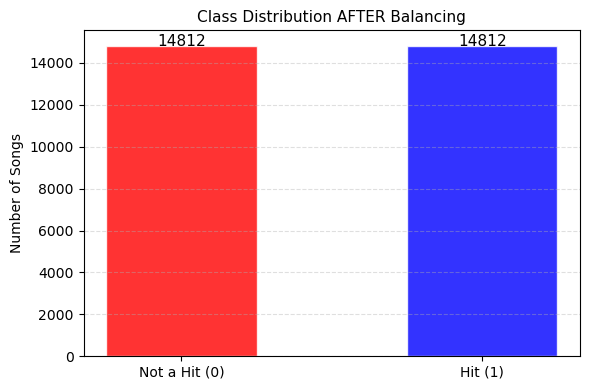

In [15]:
# verify balance
balanced_counts = df_balanced['is_hit'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(['Not a Hit (0)', 'Hit (1)'],
        [balanced_counts[0], balanced_counts[1]],
        color=['red', 'blue'], alpha=0.8, edgecolor='white', width=0.5)
plt.title('Class Distribution AFTER Balancing', fontsize=11)
plt.ylabel('Number of Songs', fontsize=10)
for i, val in enumerate([balanced_counts[0], balanced_counts[1]]):
    plt.text(i, val + 0.3, str(val), ha='center', fontsize=11)
plt.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## 3.3.3 Encoding Categorical Features 🔧

ML models work with **numbers**. Text columns like `track_genre` and `explicit` need to be converted.

We use **one-hot encoding** — turning one column with categories into several binary (0/1) columns.

```
track_genre = 'Pop'    →   genre_Pop=1, genre_Rock=0, genre_Hip-Hop=0 ...
track_genre = 'Rock'   →   genre_Pop=0, genre_Rock=1, genre_Hip-Hop=0 ...
```

In [16]:
# columns to encode
cols_to_encode = ['track_genre']

print(f"Columns before encoding: {list(df_balanced.columns)}")
print(f"Shape before: {df_balanced.shape}")

df_encoded = pd.get_dummies(df_balanced, columns=cols_to_encode)

# convert explicit bool to int
df_encoded['explicit'] = df_encoded['explicit'].astype(int)

# standardize column names
df_encoded.columns = df_encoded.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')

print(f"\nShape after: {df_encoded.shape}")
print(f"New columns: {[c for c in df_encoded.columns if 'genre' in c]}")
print("\n💡 Notice how many columns we now have — each genre became its own 0/1 column!")
print("   This is called a 'wide' dataset. More genres = more columns.")

Columns before encoding: ['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'is_hit']
Shape before: (29624, 21)

Shape after: (29624, 134)
New columns: ['track_genre_acoustic', 'track_genre_afrobeat', 'track_genre_alt_rock', 'track_genre_alternative', 'track_genre_ambient', 'track_genre_anime', 'track_genre_black_metal', 'track_genre_bluegrass', 'track_genre_blues', 'track_genre_brazil', 'track_genre_breakbeat', 'track_genre_british', 'track_genre_cantopop', 'track_genre_chicago_house', 'track_genre_children', 'track_genre_chill', 'track_genre_classical', 'track_genre_club', 'track_genre_comedy', 'track_genre_country', 'track_genre_dance', 'track_genre_dancehall', 'track_genre_death_metal', 'track_genre_deep_house', 'track_genre_detroit_techno', 'track_genre_disco', 'track_genre

---
## 3.3.4 Select Features & Label ✂️

Now we choose:
- **X (features)** — what we give the model as input
- **y (label)** — what we want the model to predict (`is_hit`)

In [17]:
# drop columns we don't want as features
drop_cols = ['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'is_hit']
feature_cols = [c for c in df_encoded.columns if c not in drop_cols]

X = df_encoded[feature_cols]
y = df_encoded['is_hit']

print("Features (X):")
for col in feature_cols:
    print(f"  • {col}")
print(f"\nTotal features: {len(feature_cols)}")
print(f"Label (y): is_hit — {y.value_counts().to_dict()}")
print()
print("💡 Note: 'key' (musical key, 0–11) is treated as a number here, but musical keys")
print("   don't actually have order (key 11 is not 'greater' than key 6).")
print("   Try the Extension: drop 'key' and see if model accuracy changes!")

Features (X):
  • duration_ms
  • explicit
  • danceability
  • energy
  • key
  • loudness
  • mode
  • speechiness
  • acousticness
  • instrumentalness
  • liveness
  • valence
  • tempo
  • time_signature
  • track_genre_acoustic
  • track_genre_afrobeat
  • track_genre_alt_rock
  • track_genre_alternative
  • track_genre_ambient
  • track_genre_anime
  • track_genre_black_metal
  • track_genre_bluegrass
  • track_genre_blues
  • track_genre_brazil
  • track_genre_breakbeat
  • track_genre_british
  • track_genre_cantopop
  • track_genre_chicago_house
  • track_genre_children
  • track_genre_chill
  • track_genre_classical
  • track_genre_club
  • track_genre_comedy
  • track_genre_country
  • track_genre_dance
  • track_genre_dancehall
  • track_genre_death_metal
  • track_genre_deep_house
  • track_genre_detroit_techno
  • track_genre_disco
  • track_genre_disney
  • track_genre_drum_and_bass
  • track_genre_dub
  • track_genre_dubstep
  • track_genre_edm
  • track_genre_electro


---
## 3.3.5 The Train/Test Split 🚂🧪

This is one of the **most important concepts** in machine learning.

**The problem:** If we train a model on all the data and then test it on the same data, it will look like it performs perfectly, but it has just memorized the answers. It won't actually work on new songs it's never seen!

**The solution:** Split the data into two groups:

```
Full dataset (100%)
        │
   ─────┴─────
   │         │
Training    Test
  (80%)     (20%)
   │         │
Model      Evaluate
learns      how well
from        it works
this        on NEW data
```

The **test set** is kept completely hidden from the model during training, it's only used at the very end to evaluate performance. Think of it like a final exam: you study from your notes (train), but the exam questions are ones you've never seen before (test).

In [18]:
# split: 80% for training, 20% for testing
# random_state=42 ensures the same split every time you run the code
# stratify=y ensures both sets have the same ratio of hits vs non-hits

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train/Test Split:")
print(f"  Training set:  {len(X_train)} rows ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Test set:      {len(X_test)} rows ({len(X_test)/len(X)*100:.0f}%)")

print("\nClass balance in training set:")
print(f"  Hit: {y_train.sum()} | Not a Hit: {(y_train==0).sum()}")

print("\nClass balance in test set:")
print(f"  Hit: {y_test.sum()} | Not a Hit: {(y_test==0).sum()}")

Train/Test Split:
  Training set:  23699 rows (80%)
  Test set:      5925 rows (20%)

Class balance in training set:
  Hit: 11850 | Not a Hit: 11849

Class balance in test set:
  Hit: 2962 | Not a Hit: 2963


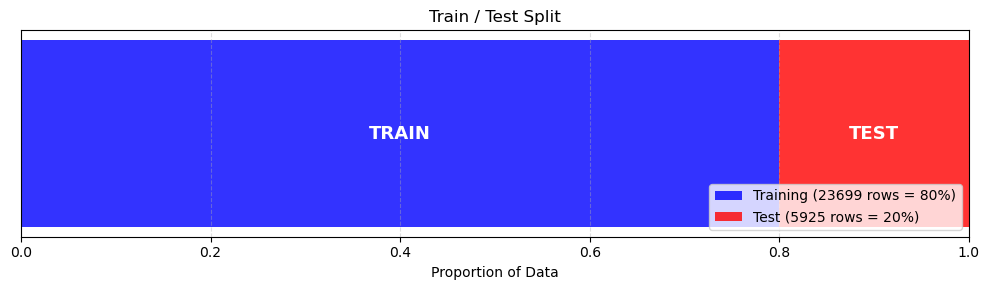

In [19]:
# visualize the split
fig, ax = plt.subplots(figsize=(10, 3))

train_pct = len(X_train) / len(X)
test_pct = len(X_test) / len(X)

ax.barh(['Dataset'], [train_pct], color='blue', alpha=0.8, label=f'Training ({len(X_train)} rows = {train_pct*100:.0f}%)')
ax.barh(['Dataset'], [test_pct], left=[train_pct], color='red', alpha=0.8, label=f'Test ({len(X_test)} rows = {test_pct*100:.0f}%)')

ax.set_xlim(0, 1)
ax.set_xlabel('Proportion of Data', fontsize=10)
ax.set_title('Train / Test Split', fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.text(train_pct / 2, 0, 'TRAIN', ha='center', va='center', fontsize=13, color='white', fontweight='bold')
ax.text(train_pct + test_pct / 2, 0, 'TEST', ha='center', va='center', fontsize=13, color='white', fontweight='bold')
ax.set_yticks([])
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

> 🏋️ **Practice 2 — Train/Test Split:**
> 1. Why do we use `stratify=y` in the split? What would go wrong without it?
> 2. Why do we use `random_state=42`? What happens if two people run the code without it?
> 3. We used an 80/20 split. What are the tradeoffs of using 90/10 vs 70/30?

**✏️ Your answers here:**

1. 

2. 

3. 

---
## 3.3.6 Save Everything for the Next Chapter 💾

In [23]:
# save the train and test sets so we can use them in Chapter 4
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Saved:")
print(f"  X_train.csv  — {X_train.shape[0]} rows × {X_train.shape[1]} features")
print(f"  X_test.csv   — {X_test.shape[0]} rows × {X_test.shape[1]} features")
print(f"  y_train.csv  — {len(y_train)} labels")
print(f"  y_test.csv   — {len(y_test)} labels")
print("\nReady for Chapter 4: Building ML Models! 🚀")

Saved:
  X_train.csv  — 23699 rows × 128 features
  X_test.csv   — 5925 rows × 128 features
  y_train.csv  — 23699 labels
  y_test.csv   — 5925 labels

Ready for Chapter 4: Building ML Models! 🚀


---
## 3.3.7 Extension Activity 🚀

**Option A — Try different thresholds:** Instead of `popularity >= 60` for a "Hit", try `popularity >= 50` or `>= 70`. How does that change the class balance?

**Option B — Try different split sizes:** Re-run the train/test split with `test_size=0.30` (70/30). How many rows are in each set now?

**Option C — Research:** Look up what a **validation set** is. Why do some ML workflows use 3 sets instead of 2 (train / validation / test)?

In [ ]:
# Option A — Try different thresholds
# your code here!


In [ ]:
# Option B — Try different split sizes
# your code here!

In [ ]:
# Option C — Research: What is a validation set?
# (This is a research question — write your answer in a markdown cell below)


**✏️ Option C — Your answer here:**

---
## ✏️ Finish This Sentence

**The reason we split data into train and test sets is...**

*(Write your answer here)*

---
## 🎉 Chapter 3.3 Summary

| Concept | Key Idea |
|---------|----------|
| Class Imbalance | When one outcome is much more common — models get biased |
| Undersampling | Reduce the majority class to balance the dataset |
| One-Hot Encoding | Convert text categories to 0/1 columns for ML |
| Features (X) | Inputs the model uses to make predictions |
| Label (y) | The output the model tries to predict |
| Train Set (80%) | Data the model **learns from** |
| Test Set (20%) | Data the model is **evaluated on** — never seen during training |
| `stratify=y` | Ensures both sets have the same class ratio |
| `random_state` | Makes the split reproducible across runs |

---

### 🏆 Chapter Challenge

Your data is **clean, balanced, encoded, and split**. Now train your first classification model!

Use a **Logistic Regression** or **Decision Tree** from scikit-learn:
1. Train it on `X_train` and `y_train`
2. Predict on `X_test`
3. Calculate the **accuracy** — what percentage of songs did the model correctly classify as Hit or Not a Hit?
4. Is the accuracy higher than simply always guessing "Not a Hit"?

In [21]:
# 🏆 Challenge — train your first classifier!
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# your code here!
# hint: model = LogisticRegression(max_iter=1000)
#        model.fit(X_train, y_train)
#        y_pred = model.predict(X_test)
#        print(accuracy_score(y_test, y_pred))


---
## 🔗 What's Next?

Your data is now **clean → explored → balanced → encoded → split**. You have `X_train`, `X_test`, `y_train`, and `y_test` ready to go.

In the next notebook, we'll use these to train our first real ML classification models and see how well they can predict a hit song! 🎵🤖